# Libraries and parameters

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from loguru import logger
from datasets.data import read_csv_files, extract_features
from datasets.processing import (
    make_columns_categorical,
    split_dataset,
    compute_time_ratios,
)
from bayesian.learn import learn_bayesian_network
from bayesian.modifiers import (
    add_public_to_target_arcs,
    add_sensible_to_target_arcs,
    simplification_1,
    extract_markov_blanket,
    filter_relevant_features,
)
from bayesian.inference import (
    build_inference_engine,
    compute_posteriors_given_sensible_features_combinations,
)
from metrics.evaluate import evaluate_bn_performance
from metrics.fairness import (
    compute_group_fairness_metrics,
    save_metrics_dict,
    compute_individual_fairness,
    analyze_individual_fairness_metrics,
    compute_individual_fairness_MRF,
)
from visualization.bayesnet import visualize_bn
from visualization.metrics import plot_boxplot_timeratios, plot_brier_vs_robustness

import sys

# KEEP LOGURU OUTPUT CLEAN but preserve level colors
logger.remove()
logger.add(sys.stdout, colorize=True, format="<level>{message}</level>")


# Check that the notebook is running from the correct directory,
# this may require adjustment depending on your setup
data_path = Path("./data/")
save_path = Path("./data/notebook_results/50split/")

data_path.mkdir(parents=True, exist_ok=True)
save_path.mkdir(parents=True, exist_ok=True)

learning_method = "tabu"
force_arcs: bool = (
    False  # Use this flag to force sensible/public to be children of the target
)
drop_duplicates: bool = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load datasets

In [3]:
_, dfs = read_csv_files((data_path / "preprocessed_data").as_posix())
logger.info(f"Datasets loaded from {data_path / 'preprocessed_data'}.")

Datasets loaded from data/preprocessed_data.


# Preprocess datasets

In [4]:
for key in dfs.keys():
    dfs[key] = make_columns_categorical(
        dfs[key], threshold=10, n_bins=5, encode="ordinal", strategy="uniform"
    )
logger.success("Datasets loaded and preprocessed successfully.")

Datasets loaded and preprocessed successfully.


# Main pipeline

1. Split datasets into training and test sets
2. Learn Bayesian Network structure and parameters
3. Evaluate model performance
4. Compute fairness and robustness metrics
5. Aggregate and visualize results

Dataset split into train (22605 rows) and test (22606 rows)
Target distribution in train: {'no': 0.8829462508294625, 'yes': 0.11705374917053749}
Target distribution in test: {'no': 0.8830841369547907, 'yes': 0.11691586304520923}
Learning parameters after adding sensible features: {}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...
Learned Bayesian network with 16 nodes and 25 arcs


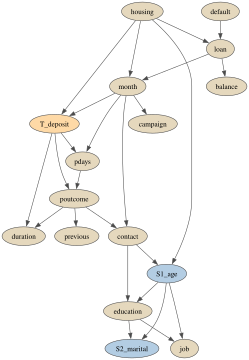

Bayesian network image saved to data/notebook_results/50split/bank_marketing/bank_marketing__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/bank_marketing
Checking for independent nodes in bank_marketing...
Saved simplified network to data/notebook_results/50split/bank_marketing as bank_marketing_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_deposit
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 22606/22606 [01:32<00:00, 243.66it/s]


Accuracy: 0.8944
Brier Score mean: 0.0822 (lower is better)
Confusion Matrix: 
[[19497   466]
 [ 1922   721]]
Classification Report: 
              precision    recall  f1-score   support

          no       0.91      0.98      0.94     19963
         yes       0.61      0.27      0.38      2643

    accuracy                           0.89     22606
   macro avg       0.76      0.62      0.66     22606
weighted avg       0.87      0.89      0.88     22606

Saved dataset with results to data/notebook_results/50split/bank_marketing/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/bank_marketing
--------------------------------------------------------------------------
Getting Markov blanket for T_deposit...
No sensible features in bank_marketing after independency check
Dataset split into train (24421 rows) and test (24421 rows)
Target distribution in train: {'<=50K': 0.7606568117603701, '>50K': 0.23934318823962983}
Target distribution in test:

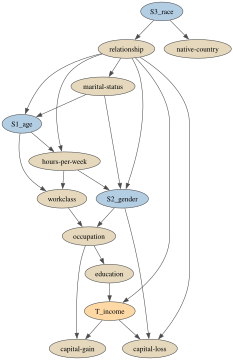

Bayesian network image saved to data/notebook_results/50split/adult/adult__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/adult
Checking for independent nodes in adult...
Saved simplified network to data/notebook_results/50split/adult as adult_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_income
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 24421/24421 [01:39<00:00, 244.54it/s]


Accuracy: 0.8292
Brier Score mean: 0.1188 (lower is better)
Confusion Matrix: 
[[17543  1036]
 [ 3134  2708]]
Classification Report: 
              precision    recall  f1-score   support

       <=50K       0.85      0.94      0.89     18579
        >50K       0.72      0.46      0.56      5842

    accuracy                           0.83     24421
   macro avg       0.79      0.70      0.73     24421
weighted avg       0.82      0.83      0.82     24421

Saved dataset with results to data/notebook_results/50split/adult/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/adult
--------------------------------------------------------------------------
Getting Markov blanket for T_income...
Node 5 has parents {6}, but they are not in the Markov blanket. Setting uniform distribution.
New sensible features for individual fairness in adult: ['S2_gender']. Old sensible features: ['S1_age', 'S3_race', 'S2_gender']
New public features for individual fa

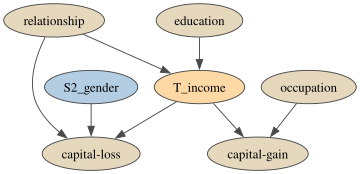

Saving Bayesian network to data/notebook_results/50split/adult
Bayesian network successfully saved to data/notebook_results/50split/adult
Loading existing results from data/notebook_results/50split/adult/adult_tabu_individual_fairness.csv
Checking for existing MRF results at data/notebook_results/50split/adult
Loading existing MRF results from data/notebook_results/50split/adult
Loaded 24421 MRF inference records from data/notebook_results/50split/adult
Plot saved to data/notebook_results/50split/adult/adult_individual_fairness_Brier_brier_vs_robustness
Plot saved to data/notebook_results/50split/adult/adult_individual_fairness_Accuracy_brier_vs_robustness
Saving boxplot to data/notebook_results/50split/adult
Dataset split into train (3607 rows) and test (3607 rows)
Target distribution in train: {0: 0.5483781535902412, 1: 0.4516218464097588}
Target distribution in test: {0: 0.5503188245079013, 1: 0.4496811754920987}
Learning parameters after adding sensible features: {}
---------------

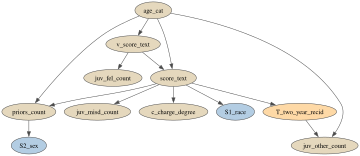

Bayesian network image saved to data/notebook_results/50split/compas-scores-two-years/compas-scores-two-years__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/compas-scores-two-years
Checking for independent nodes in compas-scores-two-years...
Saved simplified network to data/notebook_results/50split/compas-scores-two-years as compas-scores-two-years_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_two_year_recid
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 3607/3607 [00:06<00:00, 522.66it/s]


Accuracy: 0.6426
Brier Score mean: 0.2253 (lower is better)
Confusion Matrix: 
[[1288  697]
 [ 592 1030]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.69      0.65      0.67      1985
           1       0.60      0.64      0.62      1622

    accuracy                           0.64      3607
   macro avg       0.64      0.64      0.64      3607
weighted avg       0.65      0.64      0.64      3607

Saved dataset with results to data/notebook_results/50split/compas-scores-two-years/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/compas-scores-two-years
--------------------------------------------------------------------------
Getting Markov blanket for T_two_year_recid...
No sensible features in compas-scores-two-years after independency check
Dataset split into train (15000 rows) and test (15000 rows)
Target distribution in train: {0: 0.7786, 1: 0.2214}
Target distribution in test: {0: 0

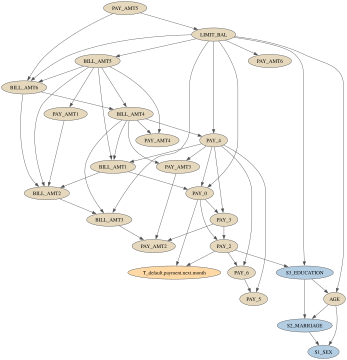

Bayesian network image saved to data/notebook_results/50split/UCI_Credit_Card/UCI_Credit_Card__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/UCI_Credit_Card
Checking for independent nodes in UCI_Credit_Card...
Saved simplified network to data/notebook_results/50split/UCI_Credit_Card as UCI_Credit_Card_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_default.payment.next.month
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 15000/15000 [00:39<00:00, 375.14it/s]


Accuracy: 0.8198
Brier Score mean: 0.1402 (lower is better)
Confusion Matrix: 
[[11267   418]
 [ 2285  1030]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.83      0.96      0.89     11685
           1       0.71      0.31      0.43      3315

    accuracy                           0.82     15000
   macro avg       0.77      0.64      0.66     15000
weighted avg       0.80      0.82      0.79     15000

Saved dataset with results to data/notebook_results/50split/UCI_Credit_Card/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/UCI_Credit_Card
--------------------------------------------------------------------------
Getting Markov blanket for T_default.payment.next.month...
Node 5 has parents {8, 0, 11}, but they are not in the Markov blanket. Setting uniform distribution.
No sensible features in UCI_Credit_Card after independency check
Dataset split into train (997 rows) and test (997 rows

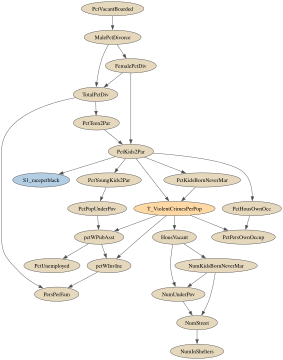

Bayesian network image saved to data/notebook_results/50split/crimedata/crimedata__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/crimedata
Checking for independent nodes in crimedata...
Saved simplified network to data/notebook_results/50split/crimedata as crimedata_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_ViolentCrimesPerPop
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 997/997 [00:04<00:00, 201.26it/s]

Accuracy: 0.7874


Brier Score mean: 0.1513 (lower is better)
Confusion Matrix: 
[[387 116]
 [ 96 398]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       503
           1       0.77      0.81      0.79       494

    accuracy                           0.79       997
   macro avg       0.79      0.79      0.79       997
weighted avg       0.79      0.79      0.79       997

Saved dataset with results to data/notebook_results/50split/crimedata/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/crimedata
--------------------------------------------------------------------------
Getting Markov blanket for T_ViolentCrimesPerPop...
Node 4 has parents {11}, but they are not in the Markov blanket. Setting uniform distribution.
Node 10 has parents {12, 7}, but they are not in the Markov blanket. Setting uniform distribution.
No sensible features in crimedata after independency check
Dataset spl

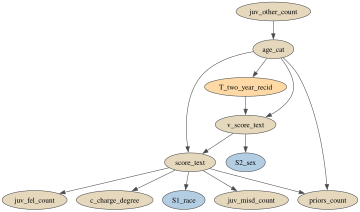

Bayesian network image saved to data/notebook_results/50split/compas-scores-two-years-violent/compas-scores-two-years-violent__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/compas-scores-two-years-violent
Checking for independent nodes in compas-scores-two-years-violent...
Saved simplified network to data/notebook_results/50split/compas-scores-two-years-violent as compas-scores-two-years-violent_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_two_year_recid
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 2369/2369 [00:04<00:00, 514.08it/s]
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Accuracy: 0.8388
Brier Score mean: 0.1257 (lower is better)
Confusion Matrix: 
[[1987    0]
 [ 382    0]]


/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d

Classification Report: 
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      1987
           1       0.00      0.00      0.00       382

    accuracy                           0.84      2369
   macro avg       0.42      0.50      0.46      2369
weighted avg       0.70      0.84      0.77      2369



/Users/eric.rossetto/Documents/Code/aequitas2025-fairness/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Saved dataset with results to data/notebook_results/50split/compas-scores-two-years-violent/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/compas-scores-two-years-violent
--------------------------------------------------------------------------
Getting Markov blanket for T_two_year_recid...
Node 1 has parents {5}, but they are not in the Markov blanket. Setting uniform distribution.
No sensible features in compas-scores-two-years-violent after independency check
Dataset split into train (324 rows) and test (325 rows)
Target distribution in train: {1: 0.845679012345679, 0: 0.15432098765432098}
Target distribution in test: {1: 0.8461538461538461, 0: 0.15384615384615385}
Learning parameters after adding sensible features: {}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...
Learned Bayesian network with 34 nodes and 28 arcs


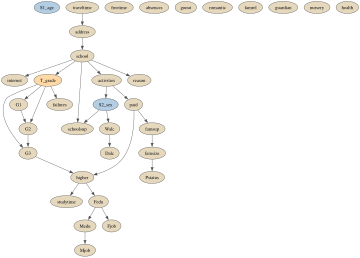

Bayesian network image saved to data/notebook_results/50split/student_por/student_por__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/student_por
Checking for independent nodes in student_por...
T_grade INDEP S1_age
T_grade INDEP freetime
T_grade INDEP absences
T_grade INDEP goout
T_grade INDEP romantic
T_grade INDEP famrel
T_grade INDEP guardian
T_grade INDEP nursery
T_grade INDEP health
Saved simplified network to data/notebook_results/50split/student_por as student_por_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_grade
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 325/325 [00:01<00:00, 233.90it/s]


Accuracy: 0.8923
Brier Score mean: 0.0795 (lower is better)
Confusion Matrix: 
[[ 34  16]
 [ 19 256]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.64      0.68      0.66        50
           1       0.94      0.93      0.94       275

    accuracy                           0.89       325
   macro avg       0.79      0.81      0.80       325
weighted avg       0.90      0.89      0.89       325

Saved dataset with results to data/notebook_results/50split/student_por/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/student_por
--------------------------------------------------------------------------
Getting Markov blanket for T_grade...
Node 0 has parents {3}, but they are not in the Markov blanket. Setting uniform distribution.
No sensible features in student_por after independency check
Dataset split into train (500 rows) and test (500 rows)
Target distribution in train: {1: 0.708, 0: 0.

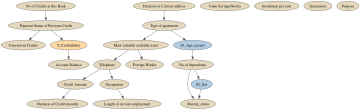

Bayesian network image saved to data/notebook_results/50split/german_credit_complete/german_credit_complete__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/german_credit_complete
Checking for independent nodes in german_credit_complete...
T_Creditability INDEP Duration of Credit (month)
T_Creditability INDEP Guarantors
T_Creditability INDEP Most valuable available asset
T_Creditability INDEP S1_Age_(years)
T_Creditability INDEP No of dependents
T_Creditability INDEP Occupation
T_Creditability INDEP S2_Sex
T_Creditability INDEP Value Savings/Stocks
T_Creditability INDEP Instalment per cent
T_Creditability INDEP Telephone
T_Creditability INDEP Marital_status
T_Creditability INDEP Purpose
T_Creditability INDEP Type of apartment
T_Creditability INDEP Length of current employment
T_Creditability INDEP Credit Amount
T_Creditability INDEP Duration in Current address
T_Creditability INDEP Foreign Worker
Saved simplified network to data/notebook_results/50split/ge

Processing test data: 100%|██████████| 500/500 [00:00<00:00, 1085.48it/s]


Accuracy: 0.7180
Brier Score mean: 0.1763 (lower is better)
Confusion Matrix: 
[[ 28 126]
 [ 15 331]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.65      0.18      0.28       154
           1       0.72      0.96      0.82       346

    accuracy                           0.72       500
   macro avg       0.69      0.57      0.55       500
weighted avg       0.70      0.72      0.66       500

Saved dataset with results to data/notebook_results/50split/german_credit_complete/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/german_credit_complete
--------------------------------------------------------------------------
Getting Markov blanket for T_Creditability...
Node 3 has parents {15}, but they are not in the Markov blanket. Setting uniform distribution.
No sensible features in german_credit_complete after independency check
Dataset split into train (15741 rows) and test (15741 rows)


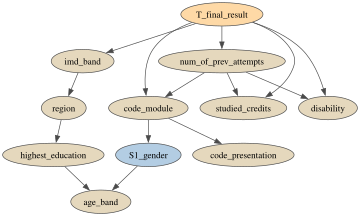

Bayesian network image saved to data/notebook_results/50split/studentInfo_OULAD/studentInfo_OULAD__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/studentInfo_OULAD
Checking for independent nodes in studentInfo_OULAD...
Saved simplified network to data/notebook_results/50split/studentInfo_OULAD as studentInfo_OULAD_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_final_result
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 15741/15741 [00:56<00:00, 279.14it/s]


Accuracy: 0.5958
Brier Score mean: 0.2362 (lower is better)
Confusion Matrix: 
[[5477 2940]
 [3423 3901]]
Classification Report: 
                precision    recall  f1-score   support

Fail/Withdrawn       0.62      0.65      0.63      8417
          Pass       0.57      0.53      0.55      7324

      accuracy                           0.60     15741
     macro avg       0.59      0.59      0.59     15741
  weighted avg       0.59      0.60      0.59     15741

Saved dataset with results to data/notebook_results/50split/studentInfo_OULAD/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/studentInfo_OULAD
--------------------------------------------------------------------------
Getting Markov blanket for T_final_result...
No sensible features in studentInfo_OULAD after independency check
Dataset split into train (197 rows) and test (198 rows)
Target distribution in train: {1: 0.6649746192893401, 0: 0.3350253807106599}
Target distribution in

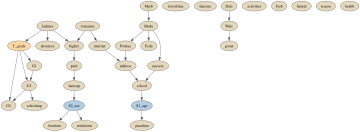

Bayesian network image saved to data/notebook_results/50split/student_mat/student_mat__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/student_mat
Checking for independent nodes in student_mat...
T_grade INDEP S1_age
T_grade INDEP address
T_grade INDEP traveltime
T_grade INDEP internet
T_grade INDEP famsize
T_grade INDEP Walc
T_grade INDEP Medu
T_grade INDEP activities
T_grade INDEP goout
T_grade INDEP Fjob
T_grade INDEP Dalc
T_grade INDEP Pstatus
T_grade INDEP Mjob
T_grade INDEP romantic
T_grade INDEP famrel
T_grade INDEP school
T_grade INDEP Fedu
T_grade INDEP reason
T_grade INDEP guardian
T_grade INDEP nursery
T_grade INDEP health
Saved simplified network to data/notebook_results/50split/student_mat as student_mat_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_grade
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 198/198 [00:00<00:00, 333.81it/s]


Accuracy: 0.8535
Brier Score mean: 0.0874 (lower is better)
Confusion Matrix: 
[[ 37  27]
 [  2 132]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.58      0.72        64
           1       0.83      0.99      0.90       134

    accuracy                           0.85       198
   macro avg       0.89      0.78      0.81       198
weighted avg       0.87      0.85      0.84       198

Saved dataset with results to data/notebook_results/50split/student_mat/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/student_mat
--------------------------------------------------------------------------
Getting Markov blanket for T_grade...
No sensible features in student_mat after independency check
Dataset split into train (50883 rows) and test (50883 rows)
Target distribution in train: {'NO': 0.5390995027808895, 'YES': 0.4609004972191105}
Target distribution in test: {'NO': 0.53913880863942

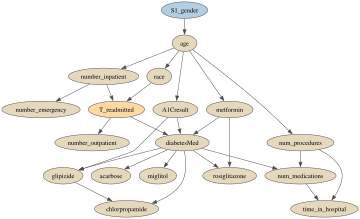

Bayesian network image saved to data/notebook_results/50split/diabetes_130/diabetes_130__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/diabetes_130
Checking for independent nodes in diabetes_130...
Saved simplified network to data/notebook_results/50split/diabetes_130 as diabetes_130_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_readmitted
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 50883/50883 [03:31<00:00, 240.50it/s]


Accuracy: 0.5517
Brier Score mean: 0.2441 (lower is better)
Confusion Matrix: 
[[26692   741]
 [22072  1378]]
Classification Report: 
              precision    recall  f1-score   support

          NO       0.55      0.97      0.70     27433
         YES       0.65      0.06      0.11     23450

    accuracy                           0.55     50883
   macro avg       0.60      0.52      0.40     50883
weighted avg       0.59      0.55      0.43     50883

Saved dataset with results to data/notebook_results/50split/diabetes_130/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/diabetes_130
--------------------------------------------------------------------------
Getting Markov blanket for T_readmitted...
Node 0 has parents {2}, but they are not in the Markov blanket. Setting uniform distribution.
Node 8 has parents {2}, but they are not in the Markov blanket. Setting uniform distribution.
Node 9 has parents {2}, but they are not in the Markov

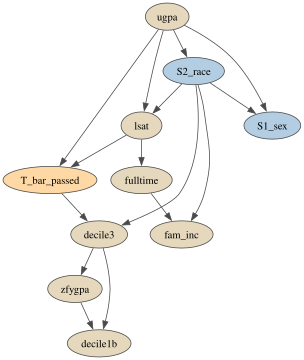

Bayesian network image saved to data/notebook_results/50split/law_bar_pass_prediction/law_bar_pass_prediction__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/law_bar_pass_prediction
Checking for independent nodes in law_bar_pass_prediction...
Saved simplified network to data/notebook_results/50split/law_bar_pass_prediction as law_bar_pass_prediction_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_bar_passed
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 10256/10256 [00:24<00:00, 422.17it/s]


Accuracy: 0.9470
Brier Score mean: 0.0427 (lower is better)
Confusion Matrix: 
[[  40  481]
 [  63 9672]]
Classification Report: 
              precision    recall  f1-score   support

       False       0.39      0.08      0.13       521
        True       0.95      0.99      0.97      9735

    accuracy                           0.95     10256
   macro avg       0.67      0.54      0.55     10256
weighted avg       0.92      0.95      0.93     10256

Saved dataset with results to data/notebook_results/50split/law_bar_pass_prediction/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/law_bar_pass_prediction
--------------------------------------------------------------------------
Getting Markov blanket for T_bar_passed...
New sensible features for individual fairness in law_bar_pass_prediction: ['S2_race']. Old sensible features: ['S1_sex', 'S2_race']
New public features for individual fairness in law_bar_pass_prediction: ['decile3', 'lsat', 

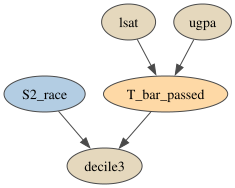

Saving Bayesian network to data/notebook_results/50split/law_bar_pass_prediction
Bayesian network successfully saved to data/notebook_results/50split/law_bar_pass_prediction
No saved file found, computing individual fairness metrics.
Computing individual fairness for law_bar_pass_prediction...


Processing rows: 100%|██████████| 10256/10256 [00:38<00:00, 266.07it/s]

Done with law_bar_pass_prediction. Processed 10256 combinations.
Saving results to data/notebook_results/50split/law_bar_pass_prediction


Features in MRF: {'decile3', 'S2_race', 'ugpa', 'lsat'}, Public features: {'decile3', 'ugpa', 'lsat'}, Sensible features: {'S2_race'}


MRF Inference: 100%|██████████| 10256/10256 [00:50<00:00, 204.31it/s]


Saving MRF inference results to data/notebook_results/50split/law_bar_pass_prediction
Plot saved to data/notebook_results/50split/law_bar_pass_prediction/law_bar_pass_prediction_individual_fairness_Brier_brier_vs_robustness
Plot saved to data/notebook_results/50split/law_bar_pass_prediction/law_bar_pass_prediction_individual_fairness_Accuracy_brier_vs_robustness
Saving boxplot to data/notebook_results/50split/law_bar_pass_prediction
Dataset split into train (30210 rows) and test (30210 rows)
Target distribution in train: {'5_4_9': 0.5239324726911618, '2_1': 0.4760675273088381}
Target distribution in test: {'5_4_9': 0.5239655743131414, '2_1': 0.47603442568685866}
Learning parameters after adding sensible features: {}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...
Learned Bayesian network with 12 nodes and 25 arcs


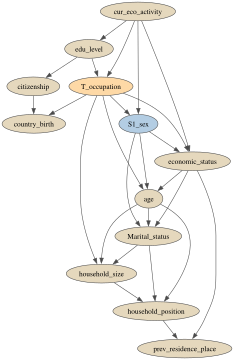

Bayesian network image saved to data/notebook_results/50split/dutch_census_2001/dutch_census_2001__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/dutch_census_2001
Checking for independent nodes in dutch_census_2001...
Saved simplified network to data/notebook_results/50split/dutch_census_2001 as dutch_census_2001_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_occupation
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 30210/30210 [03:59<00:00, 126.26it/s]


Accuracy: 0.8314
Brier Score mean: 0.1212 (lower is better)
Confusion Matrix: 
[[11449  2932]
 [ 2162 13667]]
Classification Report: 
              precision    recall  f1-score   support

         2_1       0.84      0.80      0.82     14381
       5_4_9       0.82      0.86      0.84     15829

    accuracy                           0.83     30210
   macro avg       0.83      0.83      0.83     30210
weighted avg       0.83      0.83      0.83     30210

Saved dataset with results to data/notebook_results/50split/dutch_census_2001/test_results.csv
Analyzing group fairness...
Saving results to data/notebook_results/50split/dutch_census_2001
--------------------------------------------------------------------------
Getting Markov blanket for T_occupation...
New sensible features for individual fairness in dutch_census_2001: ['S1_sex']. Old sensible features: ['S1_sex']
New public features for individual fairness in dutch_census_2001: ['age', 'household_size', 'citizenship', 'country_bi

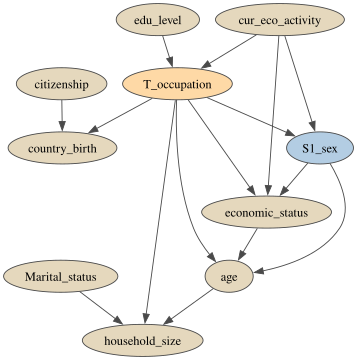

Saving Bayesian network to data/notebook_results/50split/dutch_census_2001
Bayesian network successfully saved to data/notebook_results/50split/dutch_census_2001
No saved file found, computing individual fairness metrics.
Computing individual fairness for dutch_census_2001...


Processing rows: 100%|██████████| 30210/30210 [08:07<00:00, 61.91it/s]

Done with dutch_census_2001. Processed 30210 combinations.
Saving results to data/notebook_results/50split/dutch_census_2001


Features in MRF: {'country_birth', 'economic_status', 'household_size', 'edu_level', 'citizenship', 'Marital_status', 'cur_eco_activity', 'S1_sex', 'age'}, Public features: {'country_birth', 'economic_status', 'household_size', 'edu_level', 'citizenship', 'Marital_status', 'cur_eco_activity', 'age'}, Sensible features: {'S1_sex'}


MRF Inference: 100%|██████████| 30210/30210 [08:47<00:00, 57.32it/s]


Saving MRF inference results to data/notebook_results/50split/dutch_census_2001
Plot saved to data/notebook_results/50split/dutch_census_2001/dutch_census_2001_individual_fairness_Brier_brier_vs_robustness
Plot saved to data/notebook_results/50split/dutch_census_2001/dutch_census_2001_individual_fairness_Accuracy_brier_vs_robustness
Saving boxplot to data/notebook_results/50split/dutch_census_2001
Dataset split into train (100000 rows) and test (100000 rows)
Target distribution in train: {0: 0.92561, 1: 0.07439}
Target distribution in test: {0: 0.92567, 1: 0.07433}
Learning parameters after adding sensible features: {}
--------------------------------------------------------------------------
Learning the structure of the Bayesian network...
Learned Bayesian network with 24 nodes and 59 arcs


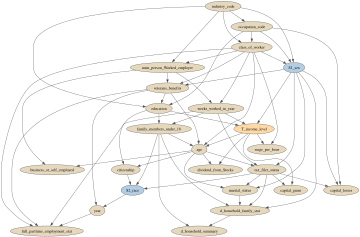

Bayesian network image saved to data/notebook_results/50split/Census_income_kdd/Census_income_kdd__tabu.pdf
Bayesian network successfully saved to data/notebook_results/50split/Census_income_kdd
Checking for independent nodes in Census_income_kdd...
Saved simplified network to data/notebook_results/50split/Census_income_kdd as Census_income_kdd_tabu_simple1.pkl
Evaluating Bayesian network performance for target: T_income_level
Duplicates not dropped from the test set


Processing test data: 100%|██████████| 100000/100000 [14:17<00:00, 116.60it/s]


Accuracy: 0.9366
Brier Score mean: 0.0476 (lower is better)
Confusion Matrix: 
[[90975  1592]
 [ 4747  2686]]
Classification Report: 
              precision    recall  f1-score   support

           0       0.95      0.98      0.97     92567
           1       0.63      0.36      0.46      7433

    accuracy                           0.94    100000
   macro avg       0.79      0.67      0.71    100000
weighted avg       0.93      0.94      0.93    100000



In [ ]:
top_metrics_to_dataset = {}
for name, dataset in dfs.items():
    # Extract features
    target, sensible_features, public_features = extract_features(dataset)
    # Split dataset into train and test sets
    train_df, test_df = split_dataset(
        df=dataset, target_column=target, test_size=0.5, random_state=42
    )

    save_path_output_dataset = save_path / name
    save_path_output_dataset.mkdir(parents=True, exist_ok=True)

    if force_arcs:
        # Add arcs from sensible features to target
        learning_params = add_sensible_to_target_arcs(
            learning_params={},
            sensible_features=sensible_features,
            target=target,
        )

        learning_params = add_public_to_target_arcs(
            learning_params=learning_params,
            public_features=public_features,
            target=target,
        )
    else:
        learning_params = {}

    logger.debug(
        f"Learning parameters after adding sensible features: {learning_params}"
    )

    # Learn Bayesian network on the training dataset
    bn = learn_bayesian_network(
        dataset=train_df,
        df_name=name,
        target=target,
        show=True,
        learning_method=learning_method,
        learning_params=learning_params,
        save_path=save_path_output_dataset.as_posix(),
    )

    bn = simplification_1(
        bn,
        name,
        target,
        save_path=save_path_output_dataset.as_posix(),
        name_prefix=f"{name}_{learning_method}_simple1",
    )

    # Update sensible features to only keep those present in the BN
    sensible_features = [feat for feat in sensible_features if feat in bn.names()]
    public_features = [feat for feat in public_features if feat in bn.names()]

    # Get all possible states of the sensible features
    sensible_states = {
        feat: list(train_df[feat].unique()) for feat in sensible_features
    }

    base_ie = build_inference_engine(bn)
    base_posterior = base_ie.posterior(target).toarray()

    # Evaluate performance on the test set
    performance_results, test_df_metrics = evaluate_bn_performance(
        bn=bn,
        ie=base_ie,
        test_df=test_df,
        target=target,
        save_path=save_path_output_dataset,
        verbose=True,
        drop_duplicates=drop_duplicates,
    )

    # Get all possible posteriors given the sensible features
    all_posteriors_comb = compute_posteriors_given_sensible_features_combinations(
        base_ie, sensible_states, target
    )

    ######################################################
    # Analyze group fairness
    ######################################################
    logger.info("Analyzing group fairness...")
    group_fairness_results = compute_group_fairness_metrics(
        base_posterior,
        all_posteriors_comb,
        target,
        tops=30,
        save_path=save_path_output_dataset,
    )

    # Save group fairness metrics
    top_kls, top_kls_against, top_manhattans, top_manhattans_against = (
        group_fairness_results
    )

    top_metrics_to_dataset = save_metrics_dict(
        name,
        top_metrics_to_dataset,
        "group_fairness",
        top_kls,
        top_kls_against,
        top_manhattans,
        top_manhattans_against,
    )

    # Get Markov blanket
    markov_blanket = extract_markov_blanket(
        bn, target, save_path=save_path_output_dataset
    )

    # Check which sensible features are relevant in Markov blanket
    new_sensible_features = filter_relevant_features(markov_blanket, sensible_features)
    new_public_features = [
        feat for feat in public_features if feat in markov_blanket.names()
    ]
    new_sensible_states = {
        feat: sensible_states[feat]
        for feat in new_sensible_features
        if feat in sensible_states
    }

    # Skip if no sensible features remain
    if not new_sensible_features:
        logger.warning(f"No sensible features in {name} after independency check")
        continue

    logger.info(
        f"New sensible features for individual fairness in {name}: {new_sensible_features}. Old sensible features: {sensible_features}",
    )
    logger.info(
        f"New public features for individual fairness in {name}: {new_public_features}. Old public features: {public_features}",
    )

    # Save the Markov blanket
    visualize_bn(
        markov_blanket,
        name,
        learning_method=learning_method,
        save_path=save_path_output_dataset.as_posix(),
        simple="blanket",
    )

    ####################################################
    # Analyze individual fairness
    ####################################################

    # Analyze individual fairness
    individual_fairness = compute_individual_fairness(
        name,
        test_df_metrics,
        markov_blanket,
        target,
        new_sensible_features,
        new_public_features,
        new_sensible_states,
        learning_method=learning_method,
        save_path=save_path_output_dataset.as_posix(),
        drop_duplicates=drop_duplicates,
    )

    # Analyze individual fairness metrics
    individual_fairness_results = analyze_individual_fairness_metrics(
        individual_fairness, target, tops=30
    )

    # Save individual fairness metrics
    top_kls_ind, top_kls_ind_against, top_man_ind, top_man_ind_against = (
        individual_fairness_results
    )
    top_metrics_to_dataset = save_metrics_dict(
        name,
        top_metrics_to_dataset,
        "individual_fairness",
        top_kls_ind,
        top_kls_ind_against,
        top_man_ind,
        top_man_ind_against,
    )

    top_metrics_to_dataset[name]["generic"] = {
        "accuracy": performance_results["accuracy"],
        "brier_score": performance_results["brier_scores"],
    }

    # Compute individual fairness metrics for Markov blanket
    individual_fairness_mrf = compute_individual_fairness_MRF(
        markov_blanket=markov_blanket,
        test_df=test_df_metrics,
        individual_fairness_df=individual_fairness,
        save_path=save_path_output_dataset.as_posix(),
    )

    plot_brier_vs_robustness(
        fairness_analysis_data=individual_fairness,
        filename_prefix=f"{name}_individual_fairness",
        robustness_column_key="Man_Robustness_Max",
        robustness_bins_strategy="quantile",
        n_bins_brier=5,
        n_bins_robustness=8,
        drop_duplicates=drop_duplicates,
        save_path=save_path_output_dataset,
        metric_name="Brier",
    )

    plot_brier_vs_robustness(
        fairness_analysis_data=individual_fairness,
        filename_prefix=f"{name}_individual_fairness",
        robustness_column_key="Man_Robustness_Max",
        robustness_bins_strategy="quantile",
        n_bins_brier=5,
        n_bins_robustness=8,
        drop_duplicates=drop_duplicates,
        save_path=save_path_output_dataset,
        metric_name="Accuracy",
    )

    timeratios = compute_time_ratios(
        individual_fairness_bn=individual_fairness,
        individual_fairness_mrf=individual_fairness_mrf,
        save_path=save_path_output_dataset,
    )

    plot_boxplot_timeratios(
        name=name,
        learning_method=learning_method,
        timeratios=timeratios,
        save_path=save_path_output_dataset,
    )